# Periodic Poisson convergence benchmark

Reads the plotting-ready JLD2 produced by `scripts/runPoisson1DPeriodicImplicitBenchmark.jl`. Edit the selection cell to compare other schemes, material wavelengths, or phase shifts.

In [12]:
import Pkg
const FLEXOPT_ROOT = normpath(joinpath(@__DIR__, ".."))
Pkg.activate(FLEXOPT_ROOT)

using CairoMakie
using JLD2
using Statistics

CairoMakie.activate!()

  Activating project at `~/Documents/Github/flexOPT`


In [13]:
result_file = joinpath(
    FLEXOPT_ROOT, "scripts", "tmp", "poisson1d_periodic",
    "poisson1d_periodic_convergence_per_delta.jld2",
)
data = load(result_file)

dx = data["dx"]
sizes = data["sizes"]
errors = data["errors"]
orders = data["orders"]
scheme_names = String.(data["scheme_names"])
case_names = String.(data["case_names"])
scheme_metadata = data["scheme_metadata"]
case_metadata = data["case_metadata"]

println(data["formula_T"])
println(data["formula_kappa"])
println(data["formula_force"])
println("\n", length(scheme_names), " schemes × ", length(case_names),
        " cases × ", length(dx), " grids")

T(x) = cos(kT*x + phiT)
kappa(x) = kappa0 + amplitude*cos(kKappa*x + phiKappa)
f(x) = amplitude*kKappa*kT*sin(kKappa*x+phiKappa)*sin(kT*x+phiT) - kappa(x)*kT^2*cos(kT*x+phiT)

9 schemes × 20 cases × 11 grids


In [14]:
scheme_names

9-element Vector{String}:
 "FD3"
 "FD5"
 "OPT3-central"
 "OPT4-field23-material23"
 "OPT4-hierarchical-B1-B2-half-W"
 "OPT4-hierarchical-B1-B2-half-all"
 "OPT5-central"
 "OPT5-hierarchical-B1-B2-B3-experimental"
 "OPT5-ordinary-hat-supp0"

## Selections

Names are stored in `scheme_names` and `case_names`; evaluate those variables to see every available choice.

In [27]:
selected_schemes = [
    "FD3",
    "FD5",
    "OPT3-central",
    #"OPT4-field23-material23",
    #"OPT4-hierarchical-B1-B2-half-W",
    #"OPT4-hierarchical-B1-B2-half-all",
    "OPT5-ordinary-hat-supp0",
    #"OPT5-central",
    #"OPT5-hierarchical-B1-B2-B3-experimental",
]

selected_cases = [
    "homogeneous",
    "kappa_k2_phase0",
    "kappa_k2_phase_pi2",
    "kappa_k4_phase_pi2",
]

scheme_index(name) = only(findall(==(name), scheme_names))
case_index(name) = only(findall(==(name), case_names))
palette = Makie.wong_colors()

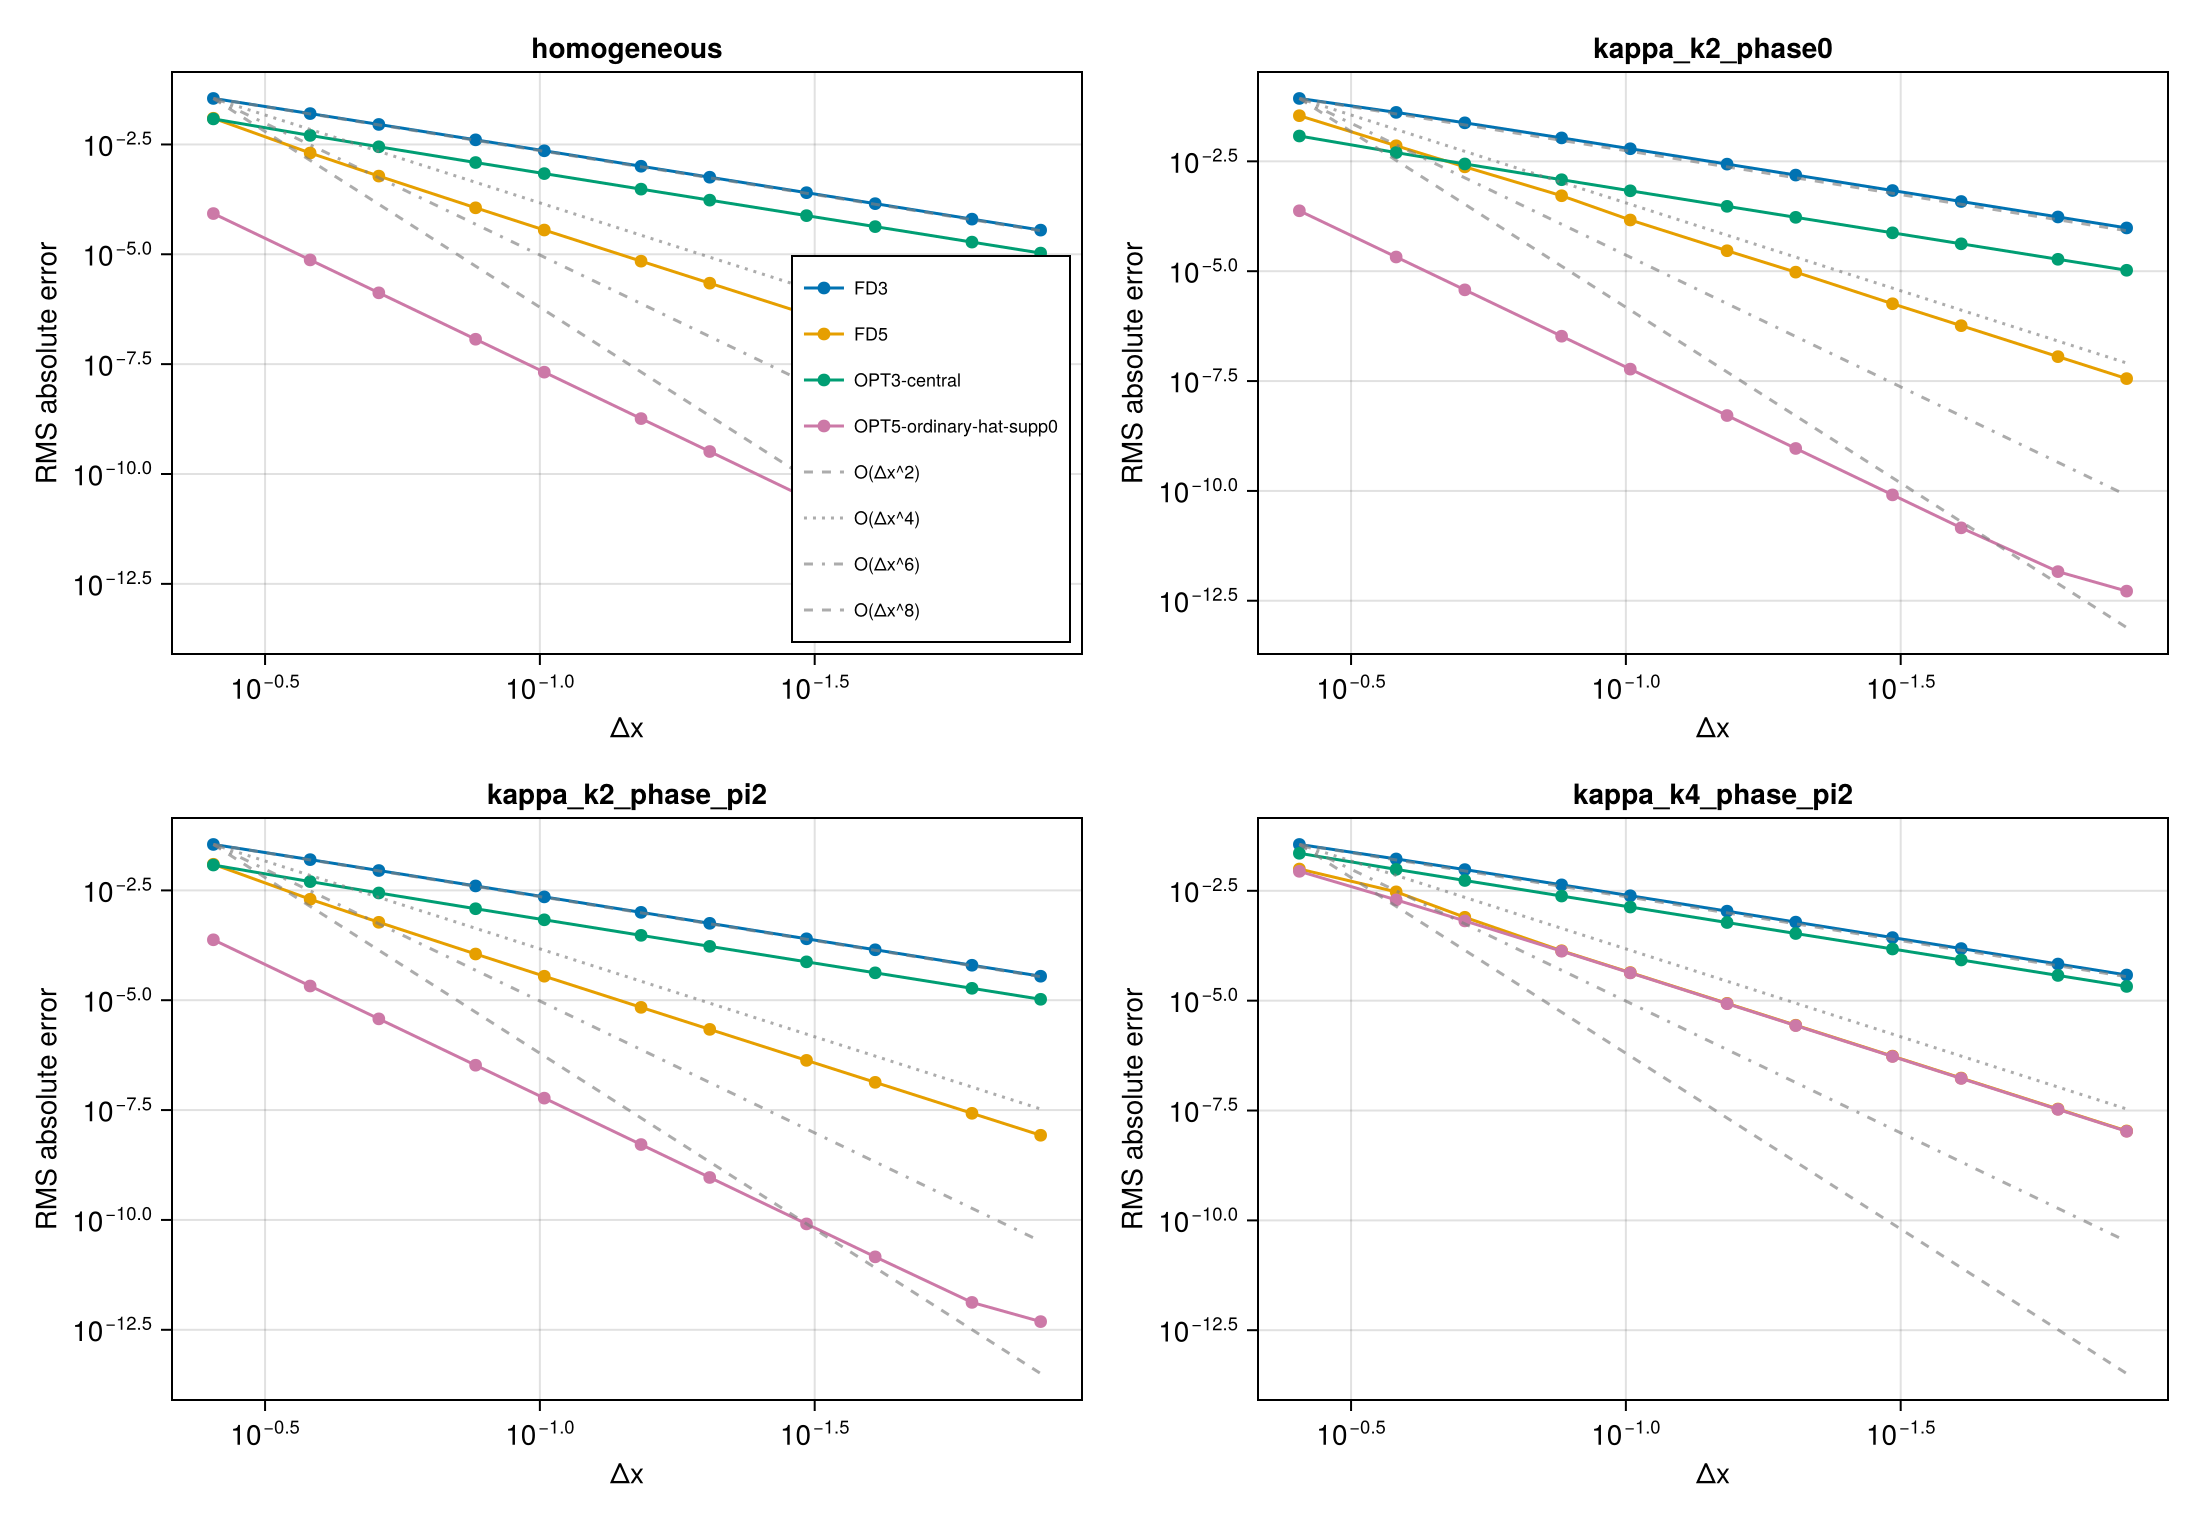

In [28]:
# Absolute RMS errors. Reference slopes are anchored to FD3 on the coarsest grid.
fig_error = Figure(size=(1100, 760))
for (panel, case_name) in enumerate(selected_cases)
    row, column = fldmod1(panel, 2)
    ci = case_index(case_name)
    ax = Axis(fig_error[row, column];
        title=case_name,
        xlabel="Δx", ylabel="RMS absolute error",
        xscale=log10, yscale=log10,
        xreversed=true,
    )
    for (line_index, scheme_name) in enumerate(selected_schemes)
        si = scheme_index(scheme_name)
        scatterlines!(ax, dx, errors[:, ci, si];
            color=palette[mod1(line_index, length(palette))],
            marker=:circle, label=scheme_name)
    end
    anchor = errors[1, ci, scheme_index("FD3")]
    for (p, style) in zip((2, 4,6,8), (:dash, :dot, :dashdot, :dash))
        lines!(ax, dx, anchor .* (dx ./ dx[1]).^p;
            color=(:grey, 0.65), linestyle=style, label="O(Δx^$p)")
    end
    panel == 1 && axislegend(ax; position=:rb, labelsize=9)
end
fig_error

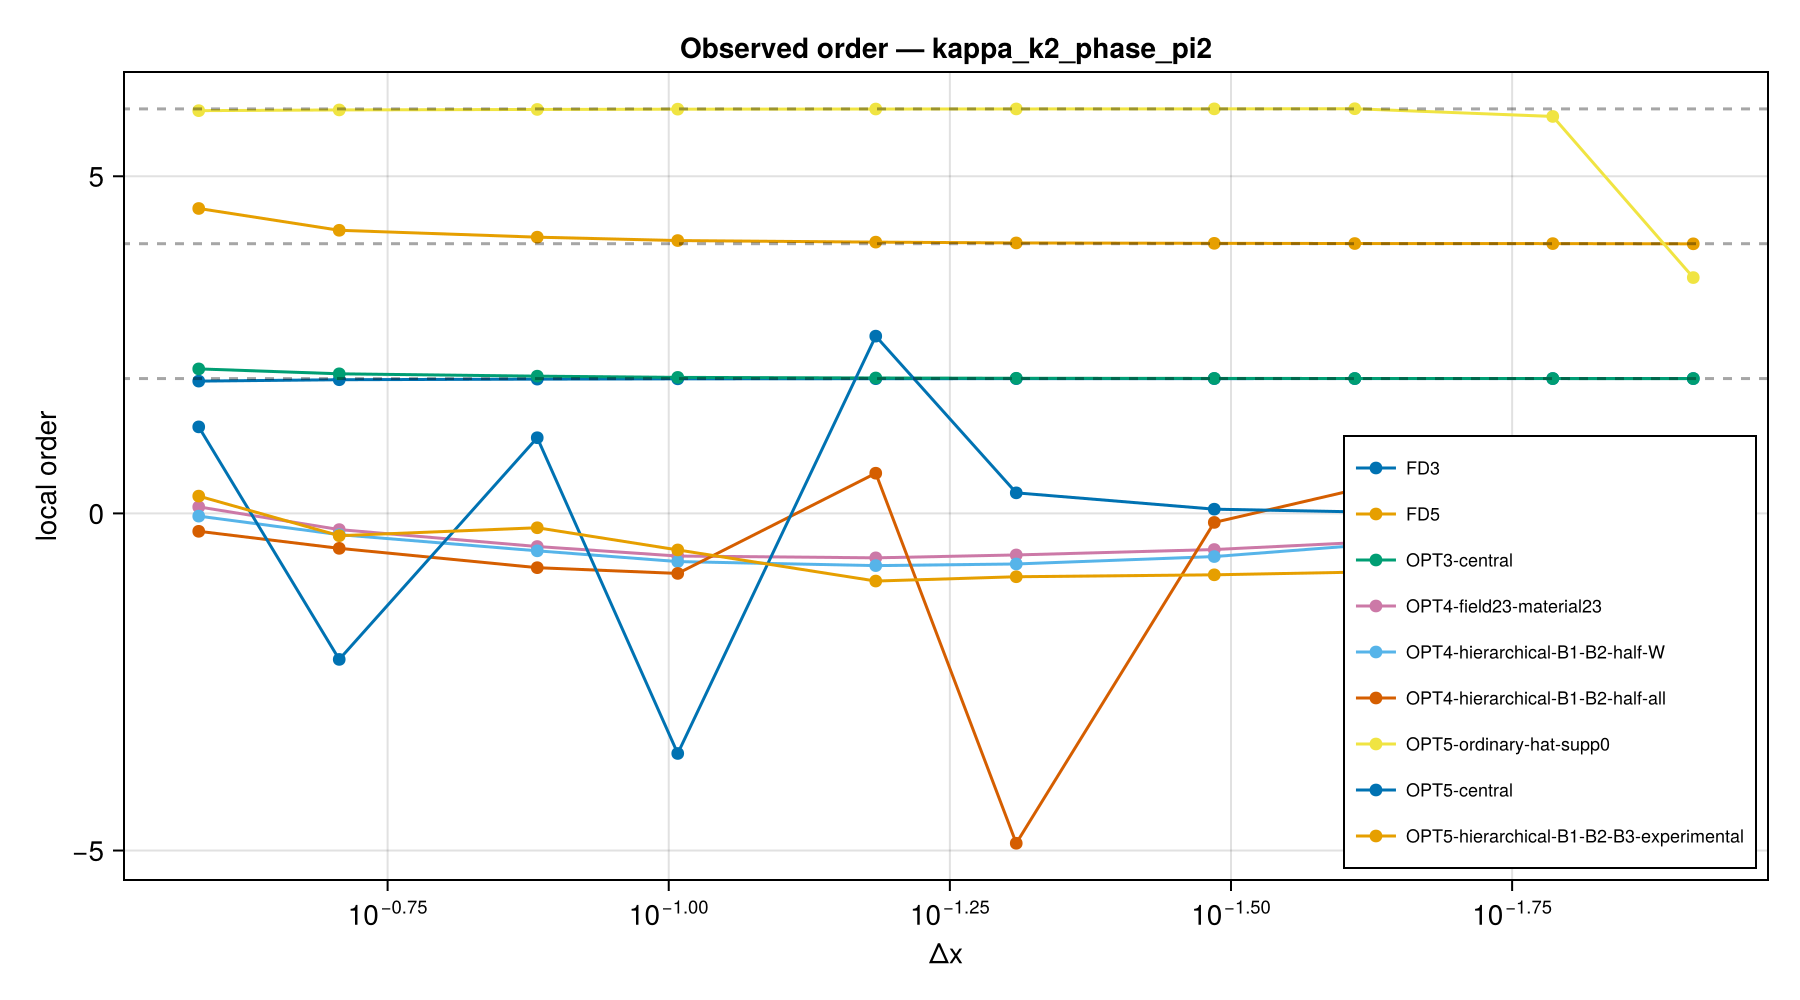

In [17]:
# Pairwise observed convergence order for one material model.
order_case = "kappa_k2_phase_pi2"
ci = case_index(order_case)
fig_order = Figure(size=(900, 500))
ax_order = Axis(fig_order[1, 1];
    title="Observed order — $order_case",
    xlabel="Δx", ylabel="local order", xscale=log10, xreversed=true)
for (line_index, scheme_name) in enumerate(selected_schemes)
    si = scheme_index(scheme_name)
    scatterlines!(ax_order, dx[2:end], orders[2:end, ci, si];
        color=palette[mod1(line_index, length(palette))],
        marker=:circle, label=scheme_name)
end
hlines!(ax_order, [2, 4, 6]; color=(:black, 0.35), linestyle=:dash)
axislegend(ax_order; position=:rb, labelsize=9)
fig_order

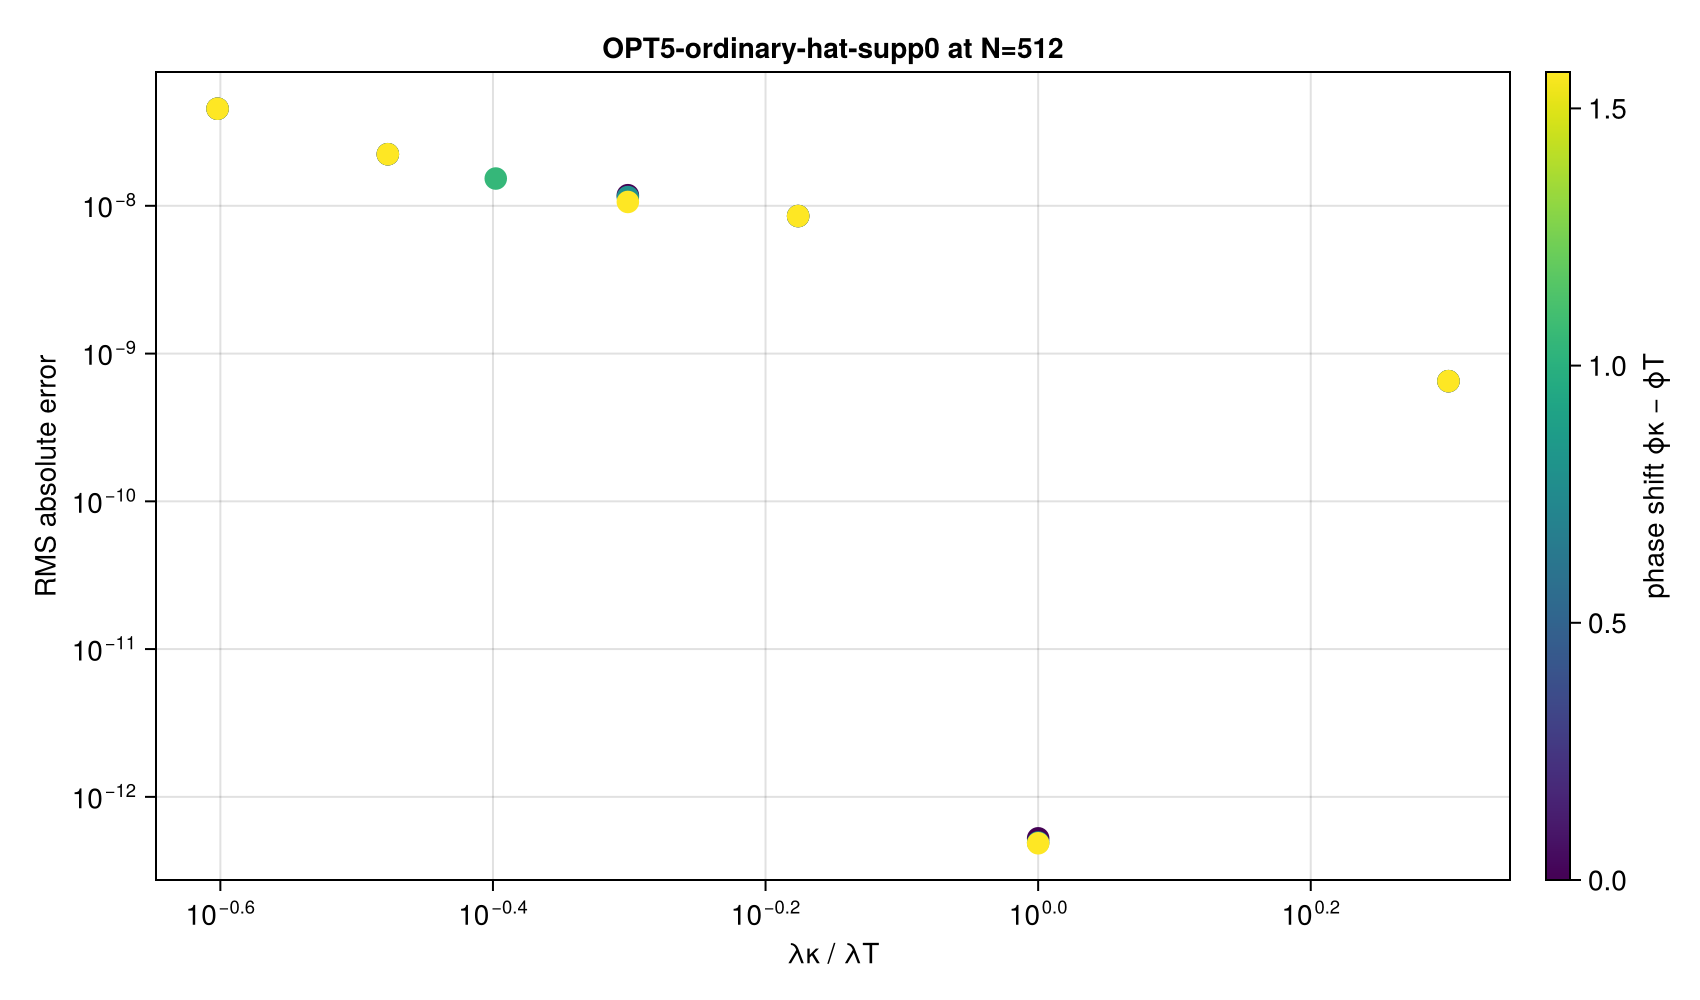

In [18]:
# Finest-grid sensitivity to material/field period ratio and phase.
ratio_scheme = "OPT5-ordinary-hat-supp0"
si = scheme_index(ratio_scheme)
heterogeneous = [i for i in eachindex(case_metadata)
                 if isfinite(case_metadata[i].period_ratio)]
ratios = [case_metadata[i].period_ratio for i in heterogeneous]
phases = [case_metadata[i].phase_shift for i in heterogeneous]
fine_errors = [errors[end, i, si] for i in heterogeneous]

fig_ratio = Figure(size=(850, 500))
ax_ratio = Axis(fig_ratio[1, 1];
    title="$ratio_scheme at N=$(sizes[end])",
    xlabel="λκ / λT", ylabel="RMS absolute error",
    xscale=log10, yscale=log10)
scatter!(ax_ratio, ratios, fine_errors;
    color=phases, colormap=:viridis, markersize=16,
    colorrange=(0, pi / 2))
Colorbar(fig_ratio[1, 2]; limits=(0, pi / 2), colormap=:viridis,
    label="phase shift ϕκ − ϕT")
fig_ratio

The full metadata for a scheme is available as `scheme_metadata[scheme_index(name)]`; each case stores `kT`, `kKappa`, `period_ratio`, `phase_shift`, `kappa0`, and `amplitude`.